In [8]:
import pandas as pd
import numpy as np


# Load cleaned dataset
df = pd.read_csv("../data/cleaned/cleaned_jobs_main.csv")

df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,...,application_deadline,job_description_length,benefits_score,company_name,experience_level_clean,employment_type_clean,company_size_clean,work_type,skills_list,skill_count
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,...,2024-07-11,1076,5.9,Smart Analytics,Senior Level,Contract,Medium,Hybrid,"['tableau', 'pytorch', 'kubernetes', 'linux', ...",5
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,...,2025-11-01,1268,5.2,TechCorp Inc,Entry Level,Contract,Medium,Remote,"['deep learning', 'aws', 'mathematics', 'pytho...",5
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,...,2025-07-04,1974,9.4,Autonomous Tech,Mid Level,Freelance,Large,On-site,"['kubernetes', 'deep learning', 'java', 'hadoo...",5
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,...,NaN,1345,8.6,Future Systems,Senior Level,Freelance,Medium,Hybrid,"['scala', 'sql', 'linux', 'python']",4
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,...,NaN,1989,6.6,Advanced Robotics,Entry Level,Part Time,Small,Remote,"['mlops', 'java', 'tableau', 'python']",4


In [2]:
def salary_band(salary):

    if salary < 50000:
        return "Low"

    elif salary < 100000:
        return "Medium"

    elif salary < 150000:
        return "High"

    else:
        return "Very High"


df["salary_band"] = df["salary_usd"].apply(salary_band)

df[["salary_usd", "salary_band"]].head()

,salary_usd,salary_band
0,90376,Medium
1,61895,Medium
2,152626,Very High
3,80215,Medium
4,54624,Medium


In [19]:
def experience_category(years):

    if years <= 2:
        return "Entry Level"

    elif years <= 5:
        return "Mid Level"

    elif years <= 10:
        return "Senior Level"

    else:
        return "Executive Level"


df["experience_category"] = df["years_experience"].apply(experience_category)

df[["years_experience", "experience_category"]].head()

,years_experience,experience_category
0,9,Senior Level
1,1,Entry Level
2,2,Entry Level
3,7,Senior Level
4,0,Entry Level


In [17]:
def role_category(title):

    title = str(title).lower()

    if "analyst" in title:
        return "Data Analyst"

    elif "engineer" in title:
        return "Data Engineer"

    elif "scientist" in title:
        return "Data Scientist"

    elif "machine learning" in title:
        return "ML Engineer"

    elif "ai" in title:
        return "AI Engineer"

    else:
        return "Other"


df["role_category"] = df["job_title"].apply(role_category)

df[["job_title", "role_category"]].head()

,job_title,role_category
0,AI Research Scientist,Data Scientist
1,AI Software Engineer,Data Engineer
2,AI Specialist,AI Engineer
3,NLP Engineer,Data Engineer
4,AI Consultant,AI Engineer


In [13]:
from collections import Counter

all_skills = []

for skills in df["skills_list"]:

    if isinstance(skills, str):
        split_skills = skills.split(",")

        all_skills.extend([skill.strip().lower() for skill in split_skills])

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "count"]
)

top_skills = top_skills.sort_values(
    by="count",
    ascending=False
)

top_skills.head(20)

,skill,count
8,'python',2127
15,'sql',1773
48,'tensorflow',1630
2,'kubernetes',1497
25,['python',1491
31,'scala',1418
1,'pytorch',1396
3,'linux',1367
29,'git',1319
12,'java',1279


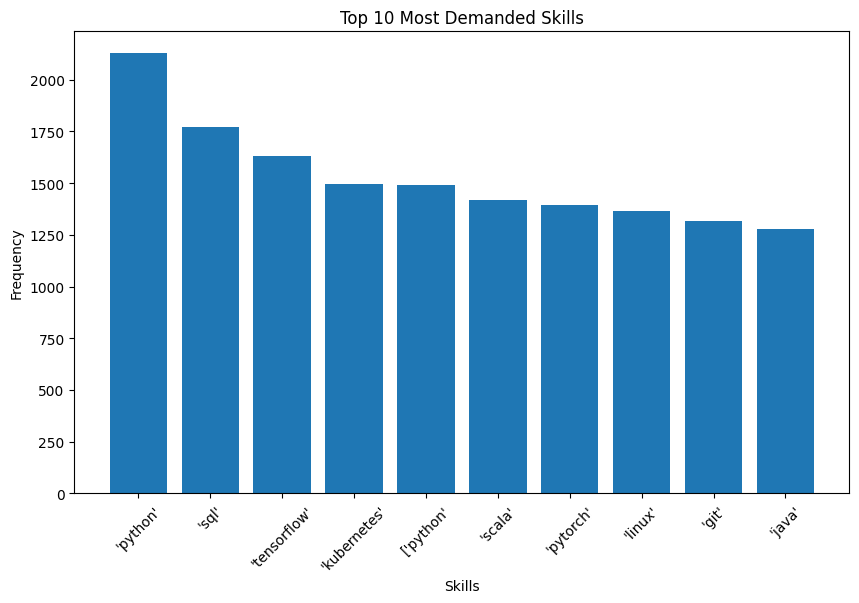

In [9]:
import matplotlib.pyplot as plt

top_10 = top_skills.head(10)

plt.figure(figsize=(10,6))

plt.bar(top_10["skill"], top_10["count"])

plt.xticks(rotation=45)

plt.title("Top 10 Most Demanded Skills")

plt.xlabel("Skills")
plt.ylabel("Frequency")

plt.show()

In [14]:
salary_by_role = df.groupby("role_category")["salary_usd"].mean().sort_values(ascending=False)

salary_by_role

role_category
AI Engineer       117013.567233
Data Scientist    116534.516938
Data Engineer     114696.615510
ML Engineer       112621.747525
Data Analyst      111321.180501
Name: salary_usd, dtype: float64

In [15]:
remote_salary = df.groupby("work_type")["salary_usd"].mean()

remote_salary

work_type
Hybrid     115776.806793
On-site    114140.231133
Remote     116160.545935
Name: salary_usd, dtype: float64

In [20]:
experience_salary = df.groupby("experience_category")["salary_usd"].mean()

experience_salary

experience_category
Entry Level         69554.778092
Executive Level    187432.459419
Mid Level           95070.076690
Senior Level       130357.267221
Name: salary_usd, dtype: float64

In [21]:
df.groupby("role_category")["skill_count"].mean()

role_category
AI Engineer       3.991108
Data Analyst      4.036891
Data Engineer     3.993796
Data Scientist    4.007114
ML Engineer       3.899752
Name: skill_count, dtype: float64

In [22]:
df.to_csv("../data/cleaned/final_jobs_dataset.csv", index=False)

print("Final engineered dataset saved!")

Final engineered dataset saved!
